In [3]:
from tdt import read_block

In [4]:
import os
import tdt
import numpy as np
import matplotlib.pyplot as plt

tank_path = "/home/danhan/freiwaldDrive/ltian/recordings/Pancho/260310"

blocks = sorted(os.listdir(tank_path))

channel = 27
store = 'RSn2'

all_data = []
all_time = []

t_offset = 0
session_times = []

for block in blocks:
    block_path = os.path.join(tank_path, block)

    data = tdt.read_block(
        block_path,
        store=store,
        channel=channel,
        t1=0,
        t2=0,  # 0 = full session
    )

    # Extract signal
    sig = data.streams[store].data.squeeze()
    fs = data.streams[store].fs

    t = np.arange(len(sig)) / fs + t_offset

    all_data.append(sig)
    all_time.append(t)
    session_times.append(t[0])
    session_times.append(t[-1])

    t_offset = t[-1] + 1/fs

read from t=0s to t=1659.53s
read from t=0s to t=2056.57s
read from t=0s to t=991.1s
read from t=0s to t=2082.66s
read from t=0s to t=1117.29s


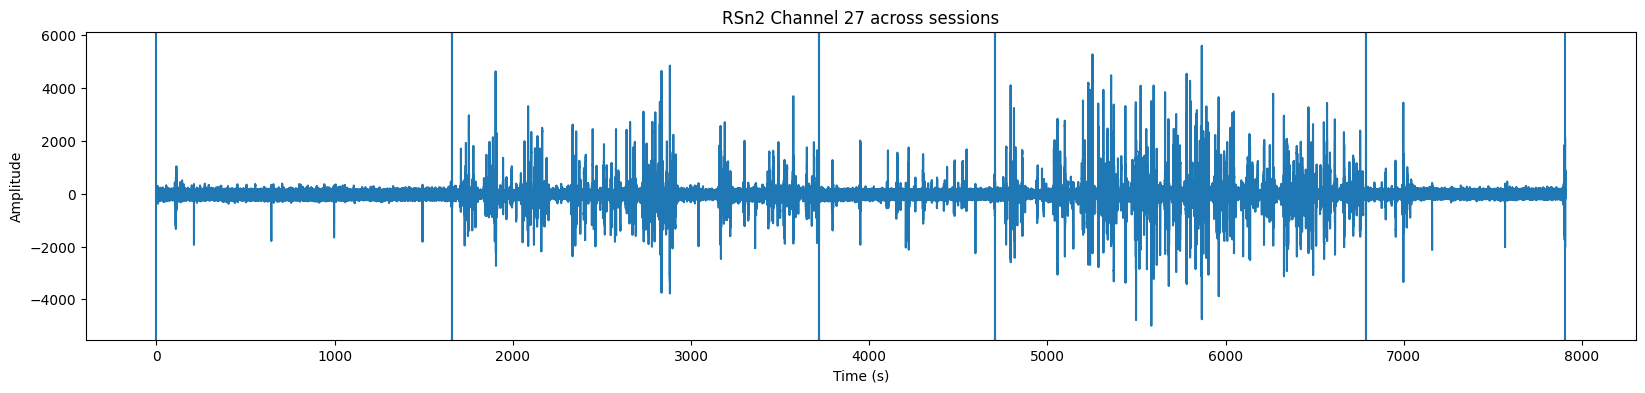

In [5]:
all_data = np.concatenate(all_data)
all_time = np.concatenate(all_time)

plt.figure(figsize=(20, 4))
plt.plot(all_time, all_data)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"{store} Channel {channel} across sessions")
for sess_bound in session_times:
    plt.axvline(sess_bound)
plt.show()

In [6]:
blocks

['Pancho-260310-154601',
 'Pancho-260310-161835',
 'Pancho-260310-165401',
 'Pancho-260310-171407',
 'Pancho-260310-175049']

In [7]:
import mat73
import pandas as pd
spikes_data = mat73.loadmat('/home/danhan/code/prims_fixation_final/Pancho/260310/spikes_postprocess/DATSTRUCT_CLEAN_MERGED.mat')['DATSTRUCT']
spikes_df = pd.DataFrame.from_dict(spikes_data)


In [8]:
spikes_df

,GOOD,Q,RSn,amps_wf,batch,chan,chan_global,clust,clust_before_merge,clust_group_id,...,isi_violation_pct,label_final,label_final_int,sharpiness,snr_aligned,snr_final,snr_not_aligned,times_sec_all,times_sec_all_BEFORE_REMOVE_DOUBLE,waveforms
0,1.0,0.3802733214497921,2.0,"[1797.0, 1949.0, 1457.0, 1333.0, 1266.0, 1293....",1.0,1.0,1.0,nan,72.0,nan,...,0.0075127368253462825,mua,1.0,6.307147821670599,4.768358094433714,4.768358094433714,4.659016339412171,"[0.008355840855638104, 0.016220161660944553, 0...",nan,"[[282.0, 248.0, 200.0, 103.0, 140.0, 356.0, 43..."
1,1.0,0.7154845928731279,2.0,"[1083.0, 1269.0, 1331.0, 1484.0, 1137.0, 1220....",1.0,5.0,5.0,nan,3.0,nan,...,0.02259375577313874,mua,1.0,5.932105044443842,3.9382925846512293,3.9382925846512293,3.354817155309369,"[0.03760128385037147, 0.053780485507121716, 0....",nan,"[[145.0, 47.0, 237.0, 240.0, -111.0, -70.0, 27..."
2,1.0,0.20818335414677147,2.0,"[1489.0, 1846.0, 1559.0, 1416.0, 1430.0, 2048....",1.0,6.0,6.0,nan,4.0,nan,...,0.00418008634276708,mua,1.0,6.158127651068928,4.6595118944776335,4.6595118944776335,4.193622701187853,"[0.08704000891289691, 0.12648449295201208, 0.1...",nan,"[[251.0, 251.0, 130.0, 243.0, 82.0, 220.0, 157..."
3,1.0,0.31142605151911434,2.0,"[1414.0, 1269.0, 1235.0, 1476.0, 1267.0, 1948....",1.0,12.0,12.0,nan,14.0,nan,...,0.004723430702299565,mua,1.0,6.014658715141185,4.172751304291791,4.172751304291791,3.631677886091723,"[0.020480002097152214, 0.053248005452595754, 0...",nan,"[[-235.0, -252.0, 118.0, 302.0, 246.0, 58.0, 3..."
4,True,0.09395973154362419,2.0,"[1709.0, 3601.0, 3628.0, 3397.0, 3440.0, 3396....",1.0,13.0,13.0,15.0,nan,2.0,...,0.006408948959565606,su,2.0,8.415056242971447,11.33278893228578,11.33278893228578,10.14545982614348,"[0.044400644546626, 0.09052160926941279, 0.128...",None,"[[274.0, 219.0, 108.0, 21.0, 74.0, 18.0, 27.0,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,1.0,0.22126069426688957,3.0,"[1294.0, 1033.0, 909.0, 1334.0, 1539.0, 1229.0...",4.0,53.0,501.0,nan,99.0,nan,...,0.006752882716442633,mua,1.0,6.081159717115748,4.343878150159667,4.343878150159667,3.974944950999551,"[0.06373376652633769, 0.1730560177209362, 0.38...",nan,"[[-109.0, 84.0, 167.0, 310.0, 88.0, 5.0, -65.0..."
210,1.0,0.7180075152611755,3.0,"[1502.0, 1332.0, 1128.0, 1666.0, 1143.0, 1020....",4.0,54.0,502.0,nan,100.0,nan,...,0.11339668317658189,mua,1.0,6.454391329325035,3.985788178343368,3.985788178343368,3.858602072087466,"[0.015441921581252769, 0.027975682864709923, 0...",nan,"[[-120.0, -69.0, 22.0, -14.0, -27.0, 83.0, -30..."
211,1.0,0.7729941745770187,3.0,"[1394.0, 2272.0, 1371.0, 1095.0, 1400.0, 2182....",4.0,57.0,505.0,nan,106.0,nan,...,0.02644425300858851,mua,1.0,6.443906614963696,5.283899200752588,5.283899200752588,5.092895505492888,"[0.10960897122395864, 0.40484868145650493, 0.4...",nan,"[[206.0, -121.0, -190.0, -31.0, 192.0, 6.0, -8..."
212,1.0,0.49219996910878866,3.0,"[1037.0, 1071.0, 1299.0, 1343.0, 1225.0, 1526....",4.0,58.0,506.0,nan,"[108.0, 126.0]",nan,...,0.007569427377734087,mua,1.0,6.23561800476986,5.049480966486731,5.049480966486731,4.697648460063612,"[0.6027674217233839, 0.846970966729827, 0.9967...",nan,"[[305.0, 314.0, 184.0, 378.0, 280.0, 293.0, 28..."


In [9]:
channel_list = [29]
df_sel = spikes_df[spikes_df['chan_global'].astype(int).isin(channel_list)]


In [10]:
df_sel

,GOOD,Q,RSn,amps_wf,batch,chan,chan_global,clust,clust_before_merge,clust_group_id,...,isi_violation_pct,label_final,label_final_int,sharpiness,snr_aligned,snr_final,snr_not_aligned,times_sec_all,times_sec_all_BEFORE_REMOVE_DOUBLE,waveforms
14,1.0,0.8305652292377304,2.0,"[2524.0, 2469.0, 1243.0, 1083.0, 1422.0, 1350....",1.0,29.0,29.0,nan,32.0,nan,...,0.07340797472117991,mua,1.0,7.316830580765074,5.210602744533745,5.210602744533745,4.789455982649894,"[0.014417921476395158, 0.016998401740636337, 0...",nan,"[[155.0, 15.0, -217.0, -176.0, -92.0, -7.0, 14..."


In [11]:
times = df_sel['times_sec_all'].to_numpy()[0]
y = np.ones(times.shape)

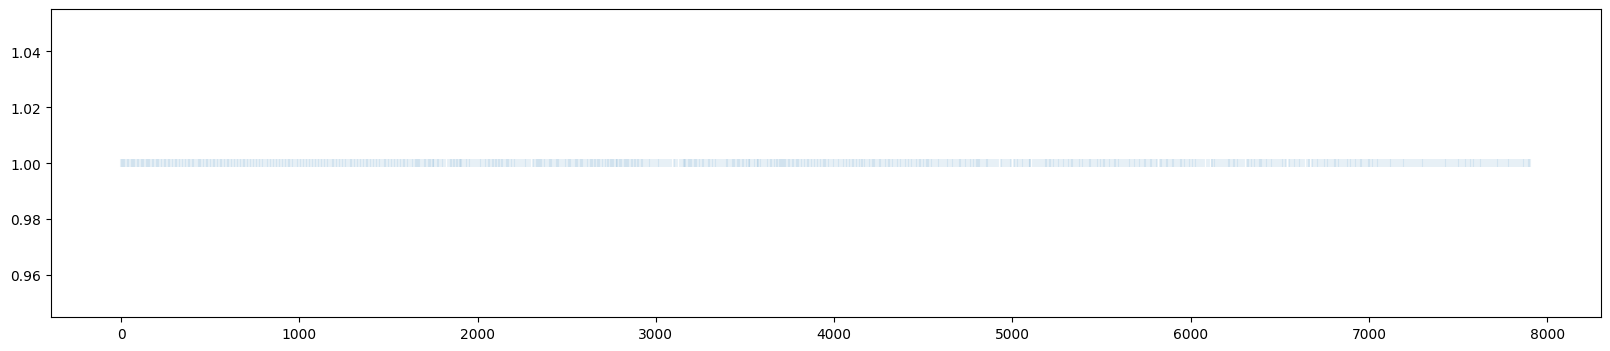

In [25]:
plt.figure(figsize=(20, 4))
plt.scatter(times[::500],y[::500],marker='|',alpha = 0.1)

In [26]:
np.max(np.diff(times))

0.4806656492201

In [27]:
np.mean(np.diff(times))

0.01716098988344508